# RandomForest Ablation 실험: feature 의존도 검증

기존 `randomforest_28_allow_block_type_v1` (28번) RandomForest 모델은 전체 BLOCK Recall ~0.946 / FPR ~0.020 / CAPTCHA BLOCK Recall ~0.929 로 우수했으나, `time_to_first_click_ms` 같은 특정 feature 에 과도하게 의존했을 가능성이 있어 검증이 필요함.

본 노트북은 동일한 train/test split 위에서 feature subset 4종 ablation 을 수행하여 다음을 검증한다.

1. **A_all_features**: 전체 feature 사용 → 28번 성능 재현 여부
2. **B_drop_time_to_first_click**: `time_to_first_click_ms` 만 제거 → 단일 feature 의존도
3. **C_drop_time_features**: time 계열 전체 제거 → time 군 의존도
4. **D_mouse_movement_only**: mouse movement feature 만 사용 → 마우스 신호 단독 탐지력

특히 CAPTCHA BLOCK Recall 이 어느 실험에서 유지되는지가 핵심 관전 포인트.

## 기존 baseline 참고값

| 모델 | 지표 | 값 |
| --- | --- | --- |
| RandomForest (28번) | overall BLOCK Recall | ~0.946 |
| RandomForest (28번) | overall FPR | ~0.020 |
| RandomForest (28번) | CAPTCHA BLOCK Recall | ~0.929 |
| Isolation Forest | overall TPR | ~0.617 |
| Isolation Forest | CAPTCHA TPR | ~0.245 |

## 1. 실험 설정

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

In [2]:
args = SimpleNamespace(
    RUN_VERSION="randomforest_ablation_allow_block_type_v1",
    DATA_ROOT="../../data/data_0514_1800_v2",
    MODEL_SAVE_DIR="../model_joblib/randomforest_ablation_allow_block_type_v1",
    RANDOM_STATE=42,
    TEST_SIZE=0.2,
    MAX_MISSING_RATE=0.3,
    SAVE_MODEL=False,
)

# 기존 baseline 참고값 (28번 RF / Isolation Forest)
BASELINE_RF_RECALL = 0.946
BASELINE_RF_FPR = 0.020
BASELINE_RF_CAPTCHA_RECALL = 0.929
BASELINE_IF_OVERALL_TPR = 0.617
BASELINE_IF_CAPTCHA_TPR = 0.245

# RandomForest 기본 파라미터 (모든 ablation 실험에서 공통 사용)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=args.RANDOM_STATE,
    n_jobs=-1,
)

print(f"RUN_VERSION: {args.RUN_VERSION}")
print(f"DATA_ROOT  : {args.DATA_ROOT}  (exists={Path(args.DATA_ROOT).exists()})")
print(f"MODEL_SAVE_DIR: {args.MODEL_SAVE_DIR}")
print(f"RANDOM_STATE={args.RANDOM_STATE}, TEST_SIZE={args.TEST_SIZE}, MAX_MISSING_RATE={args.MAX_MISSING_RATE}")
print(f"SAVE_MODEL={args.SAVE_MODEL}")

RUN_VERSION: randomforest_ablation_allow_block_type_v1
DATA_ROOT  : ../../data/data_0514_1800_v2  (exists=True)
MODEL_SAVE_DIR: ../model_joblib/randomforest_ablation_allow_block_type_v1
RANDOM_STATE=42, TEST_SIZE=0.2, MAX_MISSING_RATE=0.3
SAVE_MODEL=False


## 2. 데이터 로드

`data_0514_1800_v2/{booking,captcha,detail}/{allow,block}/*.json` 구조에서 경로 기반으로 `type`/`label_norm` 을 부여한다.  
JSON 내부 `type` 값은 사용하지 않고 파일 경로를 우선한다.

In [3]:
TYPE_MAP = {"booking": "BOOKING", "captcha": "CAPTCHA", "detail": "DETAIL"}
LABEL_MAP = {"allow": "ALLOW", "block": "BLOCK"}


def _match_from_parts(parts_lower, mapping):
    hits = [v for k, v in mapping.items() if k in parts_lower]
    return hits


def load_data(root_dir):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {root.resolve()}")
    rows = []
    n_total, n_skip = 0, 0
    for jp in sorted(root.rglob("*.json")):
        n_total += 1
        try:
            with open(jp, encoding="utf-8") as f:
                obj = json.load(f)
        except Exception as e:
            warnings.warn(f"skip {jp}: {e}")
            n_skip += 1
            continue
        flat = pd.json_normalize(obj, sep=".")
        # metrics.* nested dict 의 부모 키 prefix 제거 → feature_names 가 'reclick_rate' 형태로 깔끔하게
        flat.columns = [c.split(".", 1)[1] if c.startswith("metrics.") else c for c in flat.columns]
        parts_lower = [p.lower() for p in jp.parts]
        type_hits = _match_from_parts(parts_lower, TYPE_MAP)
        label_hits = _match_from_parts(parts_lower, LABEL_MAP)
        if len(type_hits) != 1:
            raise ValueError(f"{jp}: type matches {type_hits}")
        if len(label_hits) != 1:
            raise ValueError(f"{jp}: label matches {label_hits}")
        flat["type"] = type_hits[0]
        flat["label_norm"] = label_hits[0]
        flat["y"] = 0 if label_hits[0] == "ALLOW" else 1
        flat["source_path"] = str(jp)
        flat["source_file"] = jp.name
        rows.append(flat)
    df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    # null-mixed int 컬럼이 object dtype 으로 강등되는 걸 방지: numeric 강제 변환
    _NON_NUMERIC_META = {"type", "label_norm", "source_path", "source_file", "label"}
    for _c in df.columns:
        if _c in _NON_NUMERIC_META or _c == "y":
            continue
        if df[_c].dtype == object:
            df[_c] = pd.to_numeric(df[_c], errors="coerce")
    return df, n_total, n_skip

In [4]:
df_eda, n_total, n_skip = load_data(args.DATA_ROOT)
print(f"json files scanned: {n_total}, skipped: {n_skip}, loaded rows: {len(df_eda)}")
print(f"df_eda.shape: {df_eda.shape}")
print("columns (first 50):", df_eda.columns.tolist()[:50])

print("\n[label_norm x type]")
print(pd.crosstab(df_eda["label_norm"], df_eda["type"]))

print("\n[y distribution]")
print(df_eda["y"].value_counts().sort_index())

print("\n[type x label_norm count]")
print(df_eda.groupby(["type", "label_norm"]).size().unstack(fill_value=0))

json files scanned: 707, skipped: 0, loaded rows: 707
df_eda.shape: (707, 41)
columns (first 50): ['trialId', 'label', 'type', 'metrics.reclick_rate', 'metrics.misclick_rate', 'metrics.mouse_jerk_mean', 'metrics.double_click_rate', 'metrics.mouse_overshoot_flag', 'metrics.mousemove_event_rate', 'metrics.pre_click_scroll_flag', 'metrics.time_to_first_click_ms', 'metrics.inter_click_interval_ms', 'metrics.mouse_acceleration_mean', 'metrics.mouse_speed_change_mean', 'metrics.pre_click_hover_time_ms', 'metrics.click_offset_variance_px', 'metrics.mouse_stop_segment_count', 'metrics.mouse_avg_speed_px_per_ms', 'metrics.mouse_hover_dwell_time_ms', 'metrics.mouse_max_speed_px_per_ms', 'metrics.mouse_path_curvature_mean', 'metrics.pre_click_mousemove_count', 'metrics.click_position_repeat_rate', 'metrics.mouse_direction_change_count', 'metrics.mouse_path_straightness_score', 'metrics.edge_or_fixed_point_visit_rate', 'metrics.mouse_total_travel_distance_px', 'metrics.click_sequence_consistency_s

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_27380\573298808.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


## 3. 공통 feature 준비

- 숫자형 컬럼만 feature 후보로 사용
- id / 메타정보 / 타임스탬프 컬럼은 제외
- 결측률이 `MAX_MISSING_RATE` 보다 높은 feature 는 제외하여 `base_features` 확정
- `base_features` 가 모든 ablation 실험의 공통 모집단이 된다

In [5]:
EXCLUDE_EXACT = {
    "y", "label_norm", "type", "source_path", "source_file",
    "id", "trial_id", "trialId", "user_id", "session_id",
}
EXCLUDE_SUBSTR = ("timestamp", "created_at", "updated_at")


def is_excluded(col):
    if col in EXCLUDE_EXACT:
        return True
    c = col.lower()
    return any(s in c for s in EXCLUDE_SUBSTR)


numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [c for c in numeric_cols if not is_excluded(c)]
print(f"numeric_cols ({len(numeric_cols)}): {numeric_cols}")
print(f"\nfeature_candidates ({len(feature_candidates)}): {feature_candidates}")

numeric_cols (34): ['trialId', 'metrics.reclick_rate', 'metrics.misclick_rate', 'metrics.mouse_jerk_mean', 'metrics.double_click_rate', 'metrics.mouse_overshoot_flag', 'metrics.mousemove_event_rate', 'metrics.pre_click_scroll_flag', 'metrics.time_to_first_click_ms', 'metrics.inter_click_interval_ms', 'metrics.mouse_acceleration_mean', 'metrics.mouse_speed_change_mean', 'metrics.pre_click_hover_time_ms', 'metrics.click_offset_variance_px', 'metrics.mouse_avg_speed_px_per_ms', 'metrics.mouse_hover_dwell_time_ms', 'metrics.mouse_max_speed_px_per_ms', 'metrics.mouse_path_curvature_mean', 'metrics.pre_click_mousemove_count', 'metrics.click_position_repeat_rate', 'metrics.mouse_path_straightness_score', 'metrics.edge_or_fixed_point_visit_rate', 'metrics.mouse_total_travel_distance_px', 'metrics.click_sequence_consistency_score', 'metrics.immediate_post_render_click_rate', 'metrics.pre_click_path_300ms_straightness', 'metrics.pre_click_path_500ms_straightness', 'metrics.inter_element_move_int

In [6]:
missing_rate = df_eda[feature_candidates].isna().mean().sort_values(ascending=False)
print("[missing rate per feature]")
print(missing_rate.to_string())

excluded_by_missing = [c for c in feature_candidates if missing_rate[c] > args.MAX_MISSING_RATE]
base_features = [c for c in feature_candidates if c not in excluded_by_missing]

print(f"\nMAX_MISSING_RATE = {args.MAX_MISSING_RATE}")
print(f"excluded_by_missing ({len(excluded_by_missing)}): {excluded_by_missing}")
print(f"\nbase_features ({len(base_features)}):")
for c in base_features:
    print(f"  - {c}")

[missing rate per feature]
metrics.mouse_jerk_mean                            0.428571
metrics.inter_element_move_interval_std_ms         0.420085
metrics.click_offset_variance_px                   0.417256
metrics.inter_click_interval_ms                    0.326733
metrics.mouse_acceleration_mean                    0.216407
metrics.mouse_speed_change_mean                    0.216407
metrics.mouse_avg_speed_px_per_ms                  0.216407
metrics.mouse_max_speed_px_per_ms                  0.216407
metrics.mouse_path_straightness_score              0.216407
metrics.mouse_total_travel_distance_px             0.216407
metrics.mouse_path_curvature_mean                  0.216407
metrics.edge_or_fixed_point_visit_rate             0.216407
metrics.mouse_hover_dwell_time_ms                  0.216407
metrics.time_to_first_click_ms                     0.000000
metrics.mousemove_event_rate                       0.000000
metrics.pre_click_scroll_flag                      0.000000
metrics.pre_c

## 4. Ablation 실험 세트 정의

| 실험 | 설명 |
| --- | --- |
| `A_all_features` | `base_features` 전체 사용 (28번 재현 기준) |
| `B_drop_time_to_first_click` | `base_features` 에서 `time_to_first_click_ms` 만 제거 |
| `C_drop_time_features` | `base_features` 에서 time 계열 키워드 포함 feature 제거 |
| `D_mouse_movement_only` | `base_features` 중 마우스 움직임 키워드 포함 feature 만 사용 |

키워드 매칭은 lowercase substring 으로 한다.  
(json_normalize 로 `metrics.time_to_first_click_ms` 처럼 prefix 가 붙은 컬럼도 매칭되도록 endswith 도 함께 검사)

In [7]:
TIME_KEYWORDS = ["time", "dwell", "hover", "interval", "latency", "delay", "duration"]
MOUSE_KEYWORDS = ["mouse", "mousemove", "path", "speed", "acceleration", "jerk",
                  "curvature", "straightness", "direction", "overshoot"]

# A: 전체
A_features = list(base_features)

# B: time_to_first_click_ms 제거 (정확 일치 또는 .time_to_first_click_ms 로 끝나는 컬럼)
def _is_time_to_first_click(col):
    return col == "time_to_first_click_ms" or col.endswith(".time_to_first_click_ms")

ttfc_hits = [f for f in base_features if _is_time_to_first_click(f)]
if ttfc_hits:
    B_features = [f for f in base_features if f not in ttfc_hits]
    print(f"[B] removed time_to_first_click feature(s): {ttfc_hits}")
else:
    warnings.warn("time_to_first_click_ms not in base_features; B uses base_features as-is")
    B_features = list(base_features)

# C: time 계열 제거
C_dropped = [f for f in base_features if any(k in f.lower() for k in TIME_KEYWORDS)]
C_features = [f for f in base_features if f not in C_dropped]
print(f"\n[C] dropped {len(C_dropped)} time-related features:")
for c in C_dropped:
    print(f"  - {c}")

# D: mouse movement only
D_features = [f for f in base_features if any(k in f.lower() for k in MOUSE_KEYWORDS)]
print(f"\n[D] kept {len(D_features)} mouse-movement features:")
for c in D_features:
    print(f"  - {c}")
if len(D_features) < 5:
    warnings.warn(f"D_mouse_movement_only has only {len(D_features)} features — too few; result may be unreliable")

experiments = {
    "A_all_features":           A_features,
    "B_drop_time_to_first_click": B_features,
    "C_drop_time_features":     C_features,
    "D_mouse_movement_only":    D_features,
}

summary_rows = []
for name, feats in experiments.items():
    summary_rows.append({
        "experiment_name": name,
        "n_features": len(feats),
        "feature_list": feats,
        "dropped_features": [f for f in base_features if f not in feats],
    })
df_experiment_summary = pd.DataFrame(summary_rows)
print("\n[experiment summary]")
display(df_experiment_summary[["experiment_name", "n_features", "dropped_features"]])

[B] removed time_to_first_click feature(s): ['metrics.time_to_first_click_ms']

[C] dropped 5 time-related features:
  - metrics.time_to_first_click_ms
  - metrics.pre_click_hover_time_ms
  - metrics.mouse_hover_dwell_time_ms
  - metrics.time_from_element_visible_to_click_ms
  - metrics.time_from_element_clickable_to_click_ms

[D] kept 15 mouse-movement features:
  - metrics.mouse_overshoot_flag
  - metrics.mousemove_event_rate
  - metrics.mouse_acceleration_mean
  - metrics.mouse_speed_change_mean
  - metrics.mouse_avg_speed_px_per_ms
  - metrics.mouse_hover_dwell_time_ms
  - metrics.mouse_max_speed_px_per_ms
  - metrics.mouse_path_curvature_mean
  - metrics.pre_click_mousemove_count
  - metrics.mouse_path_straightness_score
  - metrics.mouse_total_travel_distance_px
  - metrics.pre_click_path_300ms_straightness
  - metrics.pre_click_path_500ms_straightness
  - metrics.pre_click_path_300ms_total_distance_px
  - metrics.pre_click_path_500ms_total_distance_px

[experiment summary]


,experiment_name,n_features,dropped_features
0,A_all_features,28,[]
1,B_drop_time_to_first_click,27,[metrics.time_to_first_click_ms]
2,C_drop_time_features,23,"[metrics.time_to_first_click_ms, metrics.pre_c..."
3,D_mouse_movement_only,15,"[metrics.reclick_rate, metrics.misclick_rate, ..."


## 5. 공통 train/test split

**중요**: 모든 ablation 실험은 동일한 train/test row 분할을 사용한다.  
각 실험에서는 `X_train_base` / `X_test_base` 의 열만 부분 선택하여 학습한다.

In [8]:
X_base = df_eda[base_features].copy()
y = df_eda["y"].copy()
groups_type = df_eda["type"].copy()

X_train_base, X_test_base, y_train, y_test, type_train, type_test = train_test_split(
    X_base, y, groups_type,
    test_size=args.TEST_SIZE,
    random_state=args.RANDOM_STATE,
    stratify=y,
)

print(f"X_train_base.shape: {X_train_base.shape}, X_test_base.shape: {X_test_base.shape}")
print("\n[train label distribution]")
print(y_train.value_counts().sort_index())
print("\n[test  label distribution]")
print(y_test.value_counts().sort_index())
print("\n[train type distribution]")
print(type_train.value_counts())
print("\n[test  type distribution]")
print(type_test.value_counts())

X_train_base.shape: (565, 28), X_test_base.shape: (142, 28)

[train label distribution]
y
0    195
1    370
Name: count, dtype: int64

[test  label distribution]
y
0    49
1    93
Name: count, dtype: int64

[train type distribution]
type
DETAIL     197
CAPTCHA    195
BOOKING    173
Name: count, dtype: int64

[test  type distribution]
type
DETAIL     60
CAPTCHA    43
BOOKING    39
Name: count, dtype: int64


## 6. 모델 학습 및 평가 함수

Helper 함수는 계산만 담당하고 출력은 하지 않는다. 출력은 §7 호출 루프에서 통제한다.

In [9]:
def safe_metric(fn, y_true, y_score):
    try:
        if pd.Series(y_true).nunique() < 2:
            return np.nan
        return float(fn(y_true, y_score))
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return {
        "n_samples": int(len(y_true)),
        "n_allow": int((np.asarray(y_true) == 0).sum()),
        "n_block": int((np.asarray(y_true) == 1).sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_block_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_metric(roc_auc_score, y_true, y_score),
        "average_precision": safe_metric(average_precision_score, y_true, y_score),
        "FPR": fpr,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [10]:
TYPES = ["BOOKING", "CAPTCHA", "DETAIL"]


def run_randomforest_experiment(experiment_name, feature_list):
    """한 ablation 실험 실행 후 dict 반환 (출력 없음)."""
    X_train = X_train_base[feature_list]
    X_test  = X_test_base[feature_list]

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(**RF_PARAMS)),
    ])
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    overall = compute_metrics(y_test.values, y_pred, y_proba)
    overall_row = {"experiment_name": experiment_name, "n_features": len(feature_list), **overall}

    type_rows, separation_rows = [], []
    for t in TYPES:
        mask = (type_test == t).values
        if mask.sum() == 0:
            continue
        m = compute_metrics(y_test.values[mask], y_pred[mask], y_proba[mask])
        type_rows.append({"experiment_name": experiment_name, "type": t, **m})

        proba_t = y_proba[mask]
        y_t = y_test.values[mask]
        allow_p = proba_t[y_t == 0]
        block_p = proba_t[y_t == 1]
        allow_q75 = float(np.quantile(allow_p, 0.75)) if len(allow_p) else np.nan
        block_q25 = float(np.quantile(block_p, 0.25)) if len(block_p) else np.nan
        separation_rows.append({
            "experiment_name": experiment_name,
            "type": t,
            "n_allow": int(len(allow_p)),
            "n_block": int(len(block_p)),
            "allow_proba_mean":   float(np.mean(allow_p)) if len(allow_p) else np.nan,
            "block_proba_mean":   float(np.mean(block_p)) if len(block_p) else np.nan,
            "proba_gap_mean":     (float(np.mean(block_p)) - float(np.mean(allow_p)))
                                  if (len(allow_p) and len(block_p)) else np.nan,
            "allow_proba_median": float(np.median(allow_p)) if len(allow_p) else np.nan,
            "block_proba_median": float(np.median(block_p)) if len(block_p) else np.nan,
            "proba_gap_median":   (float(np.median(block_p)) - float(np.median(allow_p)))
                                  if (len(allow_p) and len(block_p)) else np.nan,
            "allow_q75": allow_q75,
            "block_q25": block_q25,
            "separation_margin": (block_q25 - allow_q75)
                                  if (len(allow_p) and len(block_p)) else np.nan,
            "roc_auc_by_type":            safe_metric(roc_auc_score, y_t, proba_t),
            "average_precision_by_type":  safe_metric(average_precision_score, y_t, proba_t),
        })

    imp = pipeline.named_steps["model"].feature_importances_
    feature_importance_df = (
        pd.DataFrame({"feature": feature_list, "importance": imp})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "overall_row":            overall_row,
        "type_rows":              type_rows,
        "separation_rows":        separation_rows,
        "feature_importance_df": feature_importance_df,
        "pipeline":               pipeline,
    }

## 7. Ablation 실험 실행

4개 실험을 순서대로 실행하면서 호출부에서 출력을 통제한다.

In [11]:
overall_rows = []
type_rows_all = []
separation_rows_all = []
feature_importance_dict = {}
pipeline_dict = {}

for exp_name, feats in experiments.items():
    t0 = time.time()
    result = run_randomforest_experiment(exp_name, feats)
    elapsed = time.time() - t0

    overall_rows.append(result["overall_row"])
    type_rows_all.extend(result["type_rows"])
    separation_rows_all.extend(result["separation_rows"])
    feature_importance_dict[exp_name] = result["feature_importance_df"]
    pipeline_dict[exp_name] = result["pipeline"]

    o = result["overall_row"]
    print(f"\n=== [{exp_name}] fit done in {elapsed:.2f}s, n_features={len(feats)} ===")
    print(
        f"  recall_block_TPR={o['recall_block_TPR']:.4f}  FPR={o['FPR']:.4f}  "
        f"roc_auc={o['roc_auc']:.4f}  AP={o['average_precision']:.4f}  "
        f"acc={o['accuracy']:.4f}  prec={o['precision']:.4f}  f1={o['f1']:.4f}"
    )
    print("  -- type 별 성능 --")
    display(pd.DataFrame(result["type_rows"])[
        ["type", "n_samples", "n_allow", "n_block",
         "recall_block_TPR", "FPR", "roc_auc", "average_precision",
         "precision", "f1", "accuracy"]
    ])
    print("  -- feature importance top 10 --")
    display(result["feature_importance_df"].head(10))

overall_results_df        = pd.DataFrame(overall_rows)
type_results_df           = pd.DataFrame(type_rows_all)
probability_separation_df = pd.DataFrame(separation_rows_all)

print("\n[overall_results_df.shape]", overall_results_df.shape)
print("[type_results_df.shape]",     type_results_df.shape)
print("[probability_separation_df.shape]", probability_separation_df.shape)


=== [A_all_features] fit done in 0.57s, n_features=28 ===
  recall_block_TPR=0.9462  FPR=0.0204  roc_auc=0.9918  AP=0.9960  acc=0.9577  prec=0.9888  f1=0.9670
  -- type 별 성능 --


,type,n_samples,n_allow,n_block,recall_block_TPR,FPR,roc_auc,average_precision,precision,f1,accuracy
0,BOOKING,39,12,27,0.962963,0.000000,0.996914,0.998677,1.000000,0.981132,0.974359
1,CAPTCHA,43,15,28,0.928571,0.066667,0.990476,0.995268,0.962963,0.945455,0.930233
2,DETAIL,60,22,38,0.947368,0.000000,0.991627,0.995719,1.000000,0.972973,0.966667


  -- feature importance top 10 --


,feature,importance
0,metrics.time_to_first_click_ms,0.215344
1,metrics.mousemove_event_rate,0.120621
2,metrics.mouse_path_curvature_mean,0.117937
3,metrics.pre_click_mousemove_count,0.110356
4,metrics.mouse_hover_dwell_time_ms,0.086523
5,metrics.pre_click_hover_time_ms,0.081331
6,metrics.pre_click_path_300ms_straightness,0.048432
7,metrics.pre_click_path_300ms_total_distance_px,0.045563
8,metrics.mouse_acceleration_mean,0.031272
9,metrics.double_click_rate,0.018521



=== [B_drop_time_to_first_click] fit done in 0.56s, n_features=27 ===
  recall_block_TPR=0.9462  FPR=0.0612  roc_auc=0.9890  AP=0.9950  acc=0.9437  prec=0.9670  f1=0.9565
  -- type 별 성능 --


...


=== [D_mouse_movement_only] fit done in 0.57s, n_features=15 ===
  recall_block_TPR=0.9462  FPR=0.0408  roc_auc=0.9913  AP=0.9958  acc=0.9507  prec=0.9778  f1=0.9617
  -- type 별 성능 --


,type,n_samples,n_allow,n_block,recall_block_TPR,FPR,roc_auc,average_precision,precision,f1,accuracy
0,BOOKING,39,12,27,0.962963,0.083333,0.993827,0.997446,0.962963,0.962963,0.948718
1,CAPTCHA,43,15,28,0.928571,0.066667,0.992857,0.996170,0.962963,0.945455,0.930233
2,DETAIL,60,22,38,0.947368,0.000000,0.983852,0.992915,1.000000,0.972973,0.966667


  -- feature importance top 10 --


,feature,importance
0,metrics.mousemove_event_rate,0.212459
1,metrics.pre_click_mousemove_count,0.171740
2,metrics.mouse_hover_dwell_time_ms,0.151933
3,metrics.mouse_path_curvature_mean,0.128579
4,metrics.mouse_acceleration_mean,0.075264
5,metrics.pre_click_path_300ms_total_distance_px,0.070803
6,metrics.pre_click_path_300ms_straightness,0.058374
7,metrics.mouse_path_straightness_score,0.024455
8,metrics.mouse_max_speed_px_per_ms,0.023464
9,metrics.mouse_avg_speed_px_per_ms,0.017903



[overall_results_df.shape] (4, 16)
[type_results_df.shape] (12, 16)
[probability_separation_df.shape] (12, 15)


## 8. 결과 비교

### 8.1 전체 성능 비교

,experiment_name,n_features,accuracy,precision,recall_block_TPR,f1,roc_auc,average_precision,FPR,tn,fp,fn,tp,n_samples,n_allow,n_block
0,A_all_features,28,0.957746,0.988764,0.946237,0.967033,0.991771,0.995995,0.020408,48,1,5,88,142,49,93
1,B_drop_time_to_first_click,27,0.943662,0.967033,0.946237,0.956522,0.989028,0.995005,0.061224,46,3,5,88,142,49,93
2,C_drop_time_features,23,0.950704,0.977778,0.946237,0.961749,0.989247,0.995035,0.040816,47,2,5,88,142,49,93
3,D_mouse_movement_only,15,0.950704,0.977778,0.946237,0.961749,0.991332,0.995806,0.040816,47,2,5,88,142,49,93


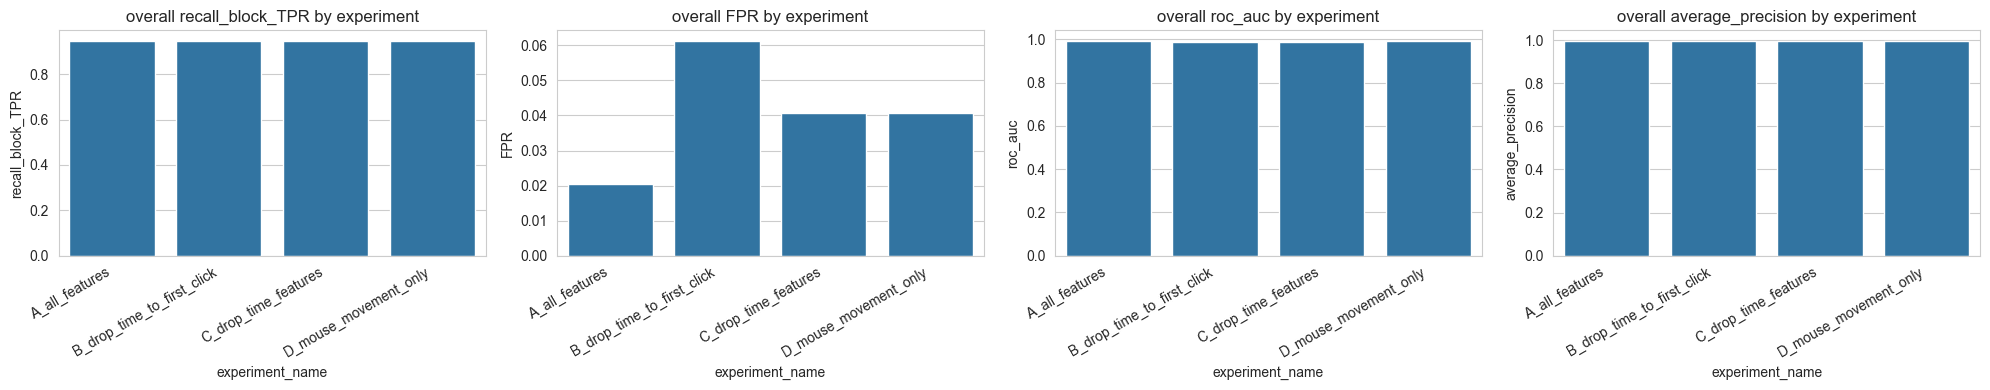

In [12]:
overall_cols = ["experiment_name", "n_features",
                "accuracy", "precision", "recall_block_TPR", "f1",
                "roc_auc", "average_precision", "FPR",
                "tn", "fp", "fn", "tp", "n_samples", "n_allow", "n_block"]
display(overall_results_df[overall_cols])

metrics_to_plot = ["recall_block_TPR", "FPR", "roc_auc", "average_precision"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=overall_results_df, x="experiment_name", y=metric, ax=ax)
    ax.set_title(f"overall {metric} by experiment")
    ax.tick_params(axis="x", rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

### 8.2 type 별 성능 비교

,experiment_name,type,n_samples,n_allow,n_block,recall_block_TPR,FPR,roc_auc,average_precision,precision,f1,accuracy
0,A_all_features,BOOKING,39,12,27,0.962963,0.000000,0.996914,0.998677,1.000000,0.981132,0.974359
1,A_all_features,CAPTCHA,43,15,28,0.928571,0.066667,0.990476,0.995268,0.962963,0.945455,0.930233
2,A_all_features,DETAIL,60,22,38,0.947368,0.000000,0.991627,0.995719,1.000000,0.972973,0.966667
3,B_drop_time_to_first_click,BOOKING,39,12,27,0.962963,0.083333,0.993827,0.997446,0.962963,0.962963,0.948718
4,B_drop_time_to_first_click,CAPTCHA,43,15,28,0.928571,0.066667,0.990476,0.995021,0.962963,0.945455,0.930233
5,B_drop_time_to_first_click,DETAIL,60,22,38,0.947368,0.045455,0.977273,0.990462,0.972973,0.960000,0.950000
6,C_drop_time_features,BOOKING,39,12,27,0.962963,0.083333,0.993827,0.997446,0.962963,0.962963,0.948718
7,C_drop_time_features,CAPTCHA,43,15,28,0.928571,0.066667,0.995238,0.997493,0.962963,0.945455,0.930233
8,C_drop_time_features,DETAIL,60,22,38,0.947368,0.000000,0.979067,0.991541,1.000000,0.972973,0.966667
9,D_mouse_movement_only,BOOKING,39,12,27,0.962963,0.083333,0.993827,0.997446,0.962963,0.962963,0.948718


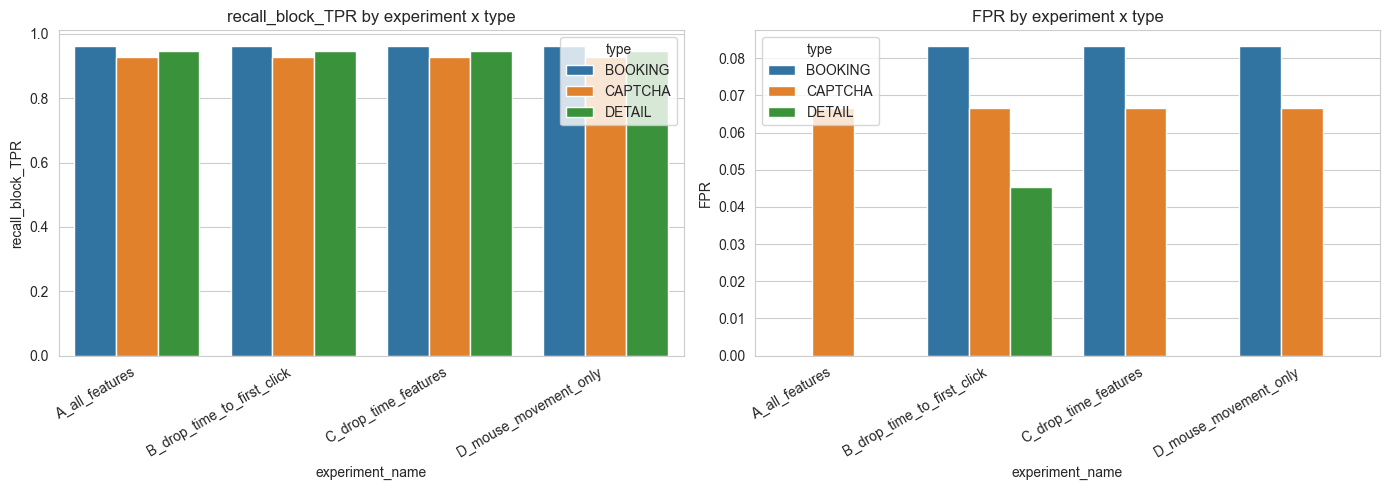


=== CAPTCHA 성능 강조 ===


,experiment_name,recall_block_TPR,FPR,roc_auc,average_precision,n_allow,n_block
0,A_all_features,0.928571,0.066667,0.990476,0.995268,15,28
1,B_drop_time_to_first_click,0.928571,0.066667,0.990476,0.995021,15,28
2,C_drop_time_features,0.928571,0.066667,0.995238,0.997493,15,28
3,D_mouse_movement_only,0.928571,0.066667,0.992857,0.996170,15,28


In [13]:
type_cols = ["experiment_name", "type", "n_samples", "n_allow", "n_block",
             "recall_block_TPR", "FPR", "roc_auc", "average_precision",
             "precision", "f1", "accuracy"]
display(type_results_df[type_cols])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=type_results_df, x="experiment_name", y="recall_block_TPR",
            hue="type", ax=axes[0])
axes[0].set_title("recall_block_TPR by experiment x type")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=type_results_df, x="experiment_name", y="FPR",
            hue="type", ax=axes[1])
axes[1].set_title("FPR by experiment x type")
axes[1].tick_params(axis="x", rotation=30)
for ax in axes:
    for lbl in ax.get_xticklabels():
        lbl.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

print("\n=== CAPTCHA 성능 강조 ===")
captcha_df = type_results_df[type_results_df["type"] == "CAPTCHA"][
    ["experiment_name", "recall_block_TPR", "FPR", "roc_auc", "average_precision",
     "n_allow", "n_block"]
].reset_index(drop=True)
display(captcha_df)

### 8.3 기존 모델 기준값과 비교

In [14]:
_overall_idx = overall_results_df.set_index("experiment_name")
full_recall = _overall_idx.loc["A_all_features", "recall_block_TPR"]
full_fpr    = _overall_idx.loc["A_all_features", "FPR"]

captcha_by_exp = (
    type_results_df[type_results_df["type"] == "CAPTCHA"]
    .set_index("experiment_name")["recall_block_TPR"]
)
full_captcha_recall = captcha_by_exp["A_all_features"]

overall_results_df["recall_drop_from_full"]        = full_recall - overall_results_df["recall_block_TPR"]
overall_results_df["fpr_change_from_full"]         = overall_results_df["FPR"] - full_fpr
overall_results_df["captcha_recall_drop_from_full"] = (
    full_captcha_recall - overall_results_df["experiment_name"].map(captcha_by_exp)
)
overall_results_df["still_better_than_isolation_overall"] = (
    overall_results_df["recall_block_TPR"] > BASELINE_IF_OVERALL_TPR
)
overall_results_df["still_better_than_isolation_captcha"] = (
    overall_results_df["experiment_name"].map(captcha_by_exp) > BASELINE_IF_CAPTCHA_TPR
)

compare_cols = ["experiment_name", "n_features", "recall_block_TPR", "FPR",
                "recall_drop_from_full", "fpr_change_from_full",
                "captcha_recall_drop_from_full",
                "still_better_than_isolation_overall",
                "still_better_than_isolation_captcha"]
display(overall_results_df[compare_cols])

,experiment_name,n_features,recall_block_TPR,FPR,recall_drop_from_full,fpr_change_from_full,captcha_recall_drop_from_full,still_better_than_isolation_overall,still_better_than_isolation_captcha
0,A_all_features,28,0.946237,0.020408,0.0,0.000000,0.0,True,True
1,B_drop_time_to_first_click,27,0.946237,0.061224,0.0,0.040816,0.0,True,True
2,C_drop_time_features,23,0.946237,0.040816,0.0,0.020408,0.0,True,True
3,D_mouse_movement_only,15,0.946237,0.040816,0.0,0.020408,0.0,True,True


## 9. Probability Distribution 비교

각 실험의 P_BLOCK 분포를 확인하여 ALLOW vs BLOCK 분리가 얼마나 잘 되는지 본다. (threshold=0.5 빨간 점선)

In [15]:
df_proba_list = []
for exp_name, pipe in pipeline_dict.items():
    feats = experiments[exp_name]
    proba = pipe.predict_proba(X_test_base[feats])[:, 1]
    df_proba_list.append(pd.DataFrame({
        "experiment_name": exp_name,
        "y_true":          y_test.values,
        "label_norm":      np.where(y_test.values == 0, "ALLOW", "BLOCK"),
        "type":            type_test.values,
        "proba_block":     proba,
    }))
df_proba_all = pd.concat(df_proba_list, ignore_index=True)
print("df_proba_all.shape:", df_proba_all.shape)
display(df_proba_all.head())

df_proba_all.shape: (568, 5)


,experiment_name,y_true,label_norm,type,proba_block
0,A_all_features,0,ALLOW,BOOKING,0.016667
1,A_all_features,1,BLOCK,BOOKING,0.196667
2,A_all_features,0,ALLOW,CAPTCHA,0.013333
3,A_all_features,1,BLOCK,CAPTCHA,0.053333
4,A_all_features,1,BLOCK,DETAIL,1.000000


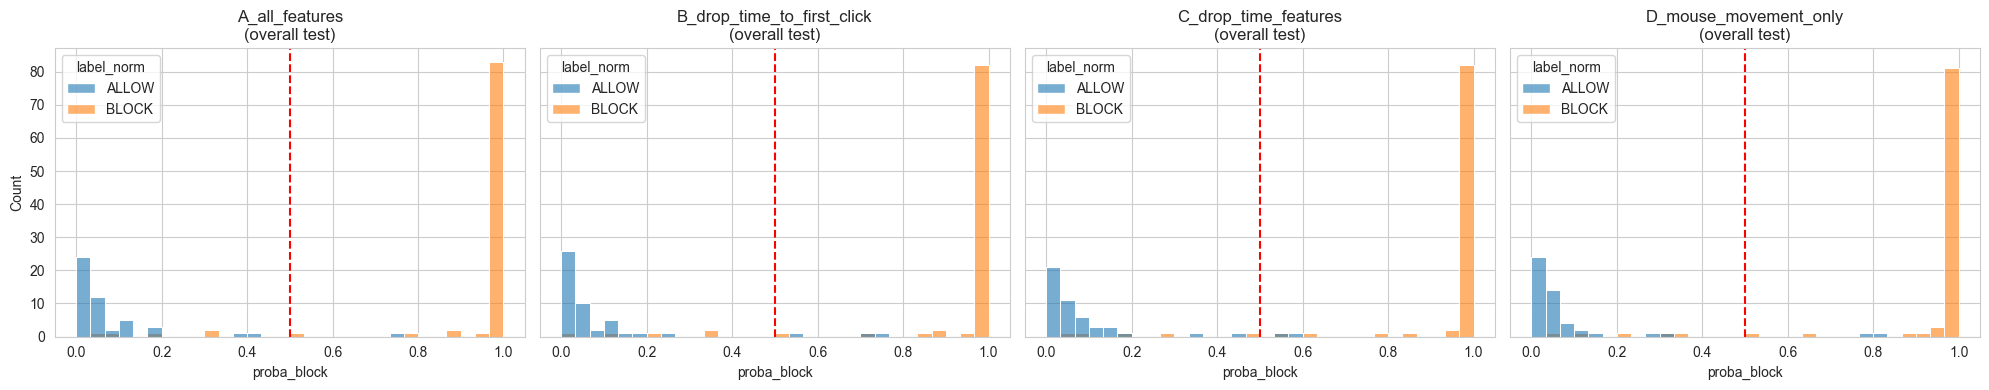

In [16]:
# 9.1 전체 test 기준 experiment 별 P_BLOCK histogram
exp_names = list(experiments.keys())
fig, axes = plt.subplots(1, len(exp_names), figsize=(5 * len(exp_names), 4), sharey=True)
for ax, exp_name in zip(axes, exp_names):
    sub = df_proba_all[df_proba_all["experiment_name"] == exp_name]
    sns.histplot(data=sub, x="proba_block", hue="label_norm",
                 bins=30, alpha=0.6, kde=False, ax=ax)
    ax.axvline(0.5, ls="--", color="red")
    ax.set_title(f"{exp_name}\n(overall test)")
plt.tight_layout()
plt.show()

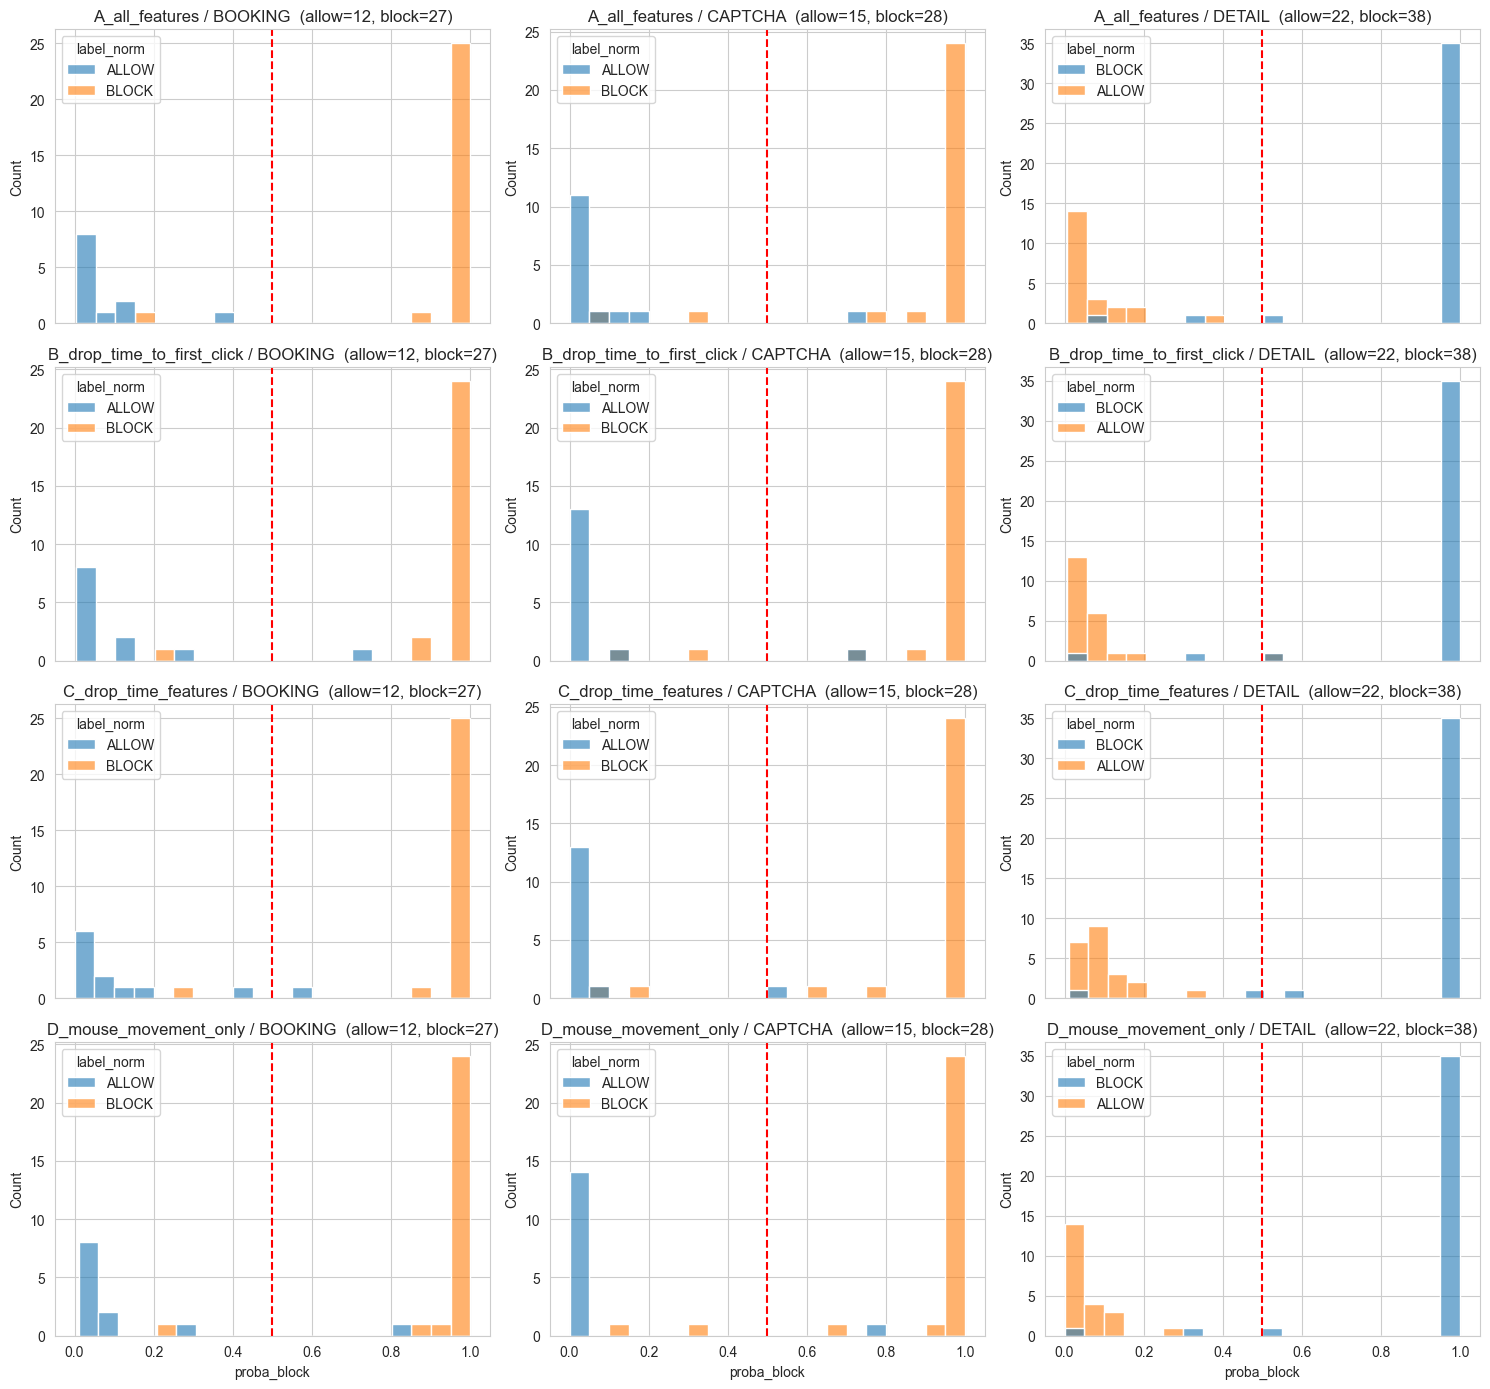

In [17]:
# 9.2 type 별 P_BLOCK histogram (experiment x type grid)
exp_names = list(experiments.keys())
fig, axes = plt.subplots(len(exp_names), len(TYPES),
                         figsize=(5 * len(TYPES), 3.5 * len(exp_names)),
                         sharex=True)
for i, exp_name in enumerate(exp_names):
    for j, t in enumerate(TYPES):
        ax = axes[i, j] if len(exp_names) > 1 else axes[j]
        sub = df_proba_all[(df_proba_all["experiment_name"] == exp_name)
                           & (df_proba_all["type"] == t)]
        if len(sub) == 0:
            ax.set_visible(False)
            continue
        sns.histplot(data=sub, x="proba_block", hue="label_norm",
                     bins=20, alpha=0.6, kde=False, ax=ax)
        ax.axvline(0.5, ls="--", color="red")
        n_a = int((sub["y_true"] == 0).sum())
        n_b = int((sub["y_true"] == 1).sum())
        ax.set_title(f"{exp_name} / {t}  (allow={n_a}, block={n_b})")
plt.tight_layout()
plt.show()

In [18]:
# 9.3 probability separation 지표
sep_cols = ["experiment_name", "type", "n_allow", "n_block",
            "allow_proba_mean", "block_proba_mean", "proba_gap_mean",
            "allow_proba_median", "block_proba_median", "proba_gap_median",
            "allow_q75", "block_q25", "separation_margin",
            "roc_auc_by_type", "average_precision_by_type"]
display(probability_separation_df[sep_cols])

neg_sep = probability_separation_df[probability_separation_df["separation_margin"] <= 0]
if len(neg_sep) > 0:
    print(f"\n[WARN] separation_margin <= 0 (experiment, type): {len(neg_sep)}건")
    display(neg_sep[["experiment_name", "type", "allow_q75", "block_q25", "separation_margin"]])
else:
    print("\nall (experiment, type) separation_margin > 0  → ALLOW q75 < BLOCK q25 분리 우수")

,experiment_name,type,n_allow,n_block,allow_proba_mean,block_proba_mean,proba_gap_mean,allow_proba_median,block_proba_median,proba_gap_median,allow_q75,block_q25,separation_margin,roc_auc_by_type,average_precision_by_type
0,A_all_features,BOOKING,12,27,0.068611,0.963951,0.895340,0.018333,1.000000,0.981667,0.080833,0.998333,0.917500,0.996914,0.998677
1,A_all_features,CAPTCHA,15,28,0.076000,0.928929,0.852929,0.010000,1.000000,0.990000,0.035000,0.996667,0.961667,0.990476,0.995268
2,A_all_features,DETAIL,22,38,0.073030,0.945614,0.872584,0.040000,1.000000,0.960000,0.081667,1.000000,0.918333,0.991627,0.995719
3,B_drop_time_to_first_click,BOOKING,12,27,0.115833,0.959753,0.843920,0.026667,1.000000,0.973333,0.119167,1.000000,0.880833,0.993827,0.997446
4,B_drop_time_to_first_click,CAPTCHA,15,28,0.068000,0.927381,0.859381,0.010000,1.000000,0.990000,0.023333,0.991667,0.968333,0.990476,0.995021
5,B_drop_time_to_first_click,DETAIL,22,38,0.075152,0.943421,0.868270,0.038333,1.000000,0.961667,0.089167,1.000000,0.910833,0.977273,0.990462
6,C_drop_time_features,BOOKING,12,27,0.130278,0.965432,0.835154,0.045000,1.000000,0.955000,0.150000,1.000000,0.850000,0.993827,0.997446
7,C_drop_time_features,CAPTCHA,15,28,0.050889,0.913690,0.862802,0.010000,0.998333,0.988333,0.030000,0.992500,0.962500,0.995238,0.997493
8,C_drop_time_features,DETAIL,22,38,0.086818,0.948772,0.861954,0.065000,1.000000,0.935000,0.109167,1.000000,0.890833,0.979067,0.991541
9,D_mouse_movement_only,BOOKING,12,27,0.126944,0.962716,0.835772,0.041667,1.000000,0.958333,0.080833,0.996667,0.915833,0.993827,0.997446



all (experiment, type) separation_margin > 0  → ALLOW q75 < BLOCK q25 분리 우수


## 10. Feature Importance 비교

time feature 를 제거했을 때 어떤 mouse movement feature 가 대체로 중요해지는지 확인한다.

In [19]:
for exp_name, df_imp in feature_importance_dict.items():
    print(f"\n=== [{exp_name}] feature importance top 20 ===")
    display(df_imp.head(20))


=== [A_all_features] feature importance top 20 ===


,feature,importance
0,metrics.time_to_first_click_ms,0.215344
1,metrics.mousemove_event_rate,0.120621
2,metrics.mouse_path_curvature_mean,0.117937
3,metrics.pre_click_mousemove_count,0.110356
4,metrics.mouse_hover_dwell_time_ms,0.086523
5,metrics.pre_click_hover_time_ms,0.081331
6,metrics.pre_click_path_300ms_straightness,0.048432
7,metrics.pre_click_path_300ms_total_distance_px,0.045563
8,metrics.mouse_acceleration_mean,0.031272
9,metrics.double_click_rate,0.018521



=== [B_drop_time_to_first_click] feature importance top 20 ===


,feature,importance
0,metrics.mousemove_event_rate,0.165023
1,metrics.pre_click_mousemove_count,0.159589
2,metrics.mouse_path_curvature_mean,0.122699
3,metrics.mouse_hover_dwell_time_ms,0.110393
4,metrics.pre_click_hover_time_ms,0.091965
5,metrics.pre_click_path_300ms_total_distance_px,0.065722
6,metrics.pre_click_path_300ms_straightness,0.060800
7,metrics.mouse_acceleration_mean,0.049540
8,metrics.click_offset_from_element_center_px,0.022471
9,metrics.double_click_rate,0.019290



=== [C_drop_time_features] feature importance top 20 ===


,feature,importance
0,metrics.mouse_path_curvature_mean,0.202838
1,metrics.mousemove_event_rate,0.177875
2,metrics.pre_click_mousemove_count,0.148066
3,metrics.mouse_acceleration_mean,0.070367
4,metrics.pre_click_path_300ms_total_distance_px,0.069849
5,metrics.double_click_rate,0.047765
6,metrics.click_offset_from_element_center_px,0.047480
7,metrics.mouse_path_straightness_score,0.040333
8,metrics.pre_click_path_300ms_straightness,0.035919
9,metrics.pre_click_path_500ms_straightness,0.027913



=== [D_mouse_movement_only] feature importance top 20 ===


,feature,importance
0,metrics.mousemove_event_rate,0.212459
1,metrics.pre_click_mousemove_count,0.171740
2,metrics.mouse_hover_dwell_time_ms,0.151933
3,metrics.mouse_path_curvature_mean,0.128579
4,metrics.mouse_acceleration_mean,0.075264
5,metrics.pre_click_path_300ms_total_distance_px,0.070803
6,metrics.pre_click_path_300ms_straightness,0.058374
7,metrics.mouse_path_straightness_score,0.024455
8,metrics.mouse_max_speed_px_per_ms,0.023464
9,metrics.mouse_avg_speed_px_per_ms,0.017903


In [20]:
freq_rows = []
for exp_name, df_imp in feature_importance_dict.items():
    top20 = df_imp.head(20).reset_index(drop=True)
    for rank, row in enumerate(top20.itertuples(index=False), start=1):
        freq_rows.append({
            "experiment_name": exp_name,
            "feature": row.feature,
            "importance": float(row.importance),
            "rank": rank,
        })
df_freq = pd.DataFrame(freq_rows)

common = (df_freq.groupby("feature")
          .agg(n_appear=("experiment_name", "nunique"),
               mean_importance=("importance", "mean"))
          .sort_values(["n_appear", "mean_importance"], ascending=[False, False]))
print("=== top 20 에 자주 등장한 feature ===")
display(common.head(30))

print("\n=== experiment 별 rank pivot ===")
rank_pivot = df_freq.pivot(index="feature", columns="experiment_name", values="rank")
rank_pivot = rank_pivot.reindex(common.index)
display(rank_pivot)

=== top 20 에 자주 등장한 feature ===


,n_appear,mean_importance
feature,,
metrics.mousemove_event_rate,4,0.168995
metrics.pre_click_mousemove_count,4,0.147438
metrics.mouse_path_curvature_mean,4,0.143013
metrics.pre_click_path_300ms_total_distance_px,4,0.062984
metrics.mouse_acceleration_mean,4,0.056611
metrics.pre_click_path_300ms_straightness,4,0.050881
metrics.mouse_path_straightness_score,4,0.022752
metrics.mouse_max_speed_px_per_ms,4,0.020329
metrics.pre_click_path_500ms_straightness,4,0.016092



=== experiment 별 rank pivot ===


experiment_name,A_all_features,B_drop_time_to_first_click,C_drop_time_features,D_mouse_movement_only
feature,,,,
metrics.mousemove_event_rate,2.0,1.0,2.0,1.0
metrics.pre_click_mousemove_count,4.0,2.0,3.0,2.0
metrics.mouse_path_curvature_mean,3.0,3.0,1.0,4.0
metrics.pre_click_path_300ms_total_distance_px,8.0,6.0,5.0,6.0
metrics.mouse_acceleration_mean,9.0,8.0,4.0,5.0
metrics.pre_click_path_300ms_straightness,7.0,7.0,9.0,7.0
metrics.mouse_path_straightness_score,13.0,14.0,8.0,8.0
metrics.mouse_max_speed_px_per_ms,12.0,11.0,11.0,9.0
metrics.pre_click_path_500ms_straightness,17.0,16.0,10.0,12.0


## 11. Optional 모델 저장

`args.SAVE_MODEL=True` 일 때만 `model_joblib/randomforest_ablation_allow_block_type_v1/` 아래에 저장한다.

다른 모델 폴더 (`isolation_*`, `logistic_9_g1_v1`) 와 동일한 3-file 컨벤션:

```
model_joblib/randomforest_ablation_allow_block_type_v1/
  ├── A_all_features/{model.joblib, meta.json, metrics.json}
  ├── B_drop_time_to_first_click/{model.joblib, meta.json, metrics.json}
  ├── C_drop_time_features/{model.joblib, meta.json, metrics.json}
  └── D_mouse_movement_only/{model.joblib, meta.json, metrics.json}
```

- `model.joblib`: 학습된 sklearn Pipeline (SimpleImputer + RandomForestClassifier)
- `meta.json`: feature_names / model_params / dataset 설정 / 실험 컨텍스트
- `metrics.json`: overall 성능 + type 별 성능 + probability separation

csv/png/md/html 저장은 금지.

In [ ]:
from datetime import datetime


def _json_safe(x):
    """JSON 직렬화용 변환 (numpy/pandas dtype, NaN → None)."""
    if isinstance(x, dict):
        return {str(k): _json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_json_safe(v) for v in x]
    if isinstance(x, np.ndarray):
        return [_json_safe(v) for v in x.tolist()]
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        f = float(x)
        return None if f != f else f  # NaN → None
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, float):
        return None if x != x else x
    return x


if args.SAVE_MODEL:
    os.makedirs(args.MODEL_SAVE_DIR, exist_ok=True)
    trained_at = datetime.now().isoformat(timespec="seconds")

    n_train_total = int(len(y_train))
    n_test_total  = int(len(y_test))

    for exp_name, pipe in pipeline_dict.items():
        exp_dir = os.path.join(args.MODEL_SAVE_DIR, exp_name)
        os.makedirs(exp_dir, exist_ok=True)

        # 1) model.joblib
        model_path = os.path.join(exp_dir, "model.joblib")
        joblib.dump(pipe, model_path)

        # 2) meta.json
        feats = experiments[exp_name]
        meta = {
            "model_name": f"{args.RUN_VERSION}/{exp_name}",
            "run_version": args.RUN_VERSION,
            "experiment_name": exp_name,
            "trained_at": trained_at,
            "label_mapping": {"ALLOW": 0, "BLOCK": 1},
            "feature_names": feats,
            "n_features": len(feats),
            "dropped_features": [f for f in base_features if f not in feats],
            "dataset": {
                "data_root": args.DATA_ROOT,
                "test_size": args.TEST_SIZE,
                "random_state": args.RANDOM_STATE,
                "max_missing_rate": args.MAX_MISSING_RATE,
                "n_train": n_train_total,
                "n_test":  n_test_total,
            },
            "model_params": RF_PARAMS,
            "ablation": {
                "base_features": base_features,
                "excluded_by_missing": excluded_by_missing,
                "all_experiments": list(experiments.keys()),
            },
        }
        meta_path = os.path.join(exp_dir, "meta.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(_json_safe(meta), f, ensure_ascii=False, indent=2)

        # 3) metrics.json
        overall_row = next(r for r in overall_rows if r["experiment_name"] == exp_name)
        type_block = {
            r["type"]: {k: v for k, v in r.items() if k not in ("experiment_name", "type")}
            for r in type_rows_all if r["experiment_name"] == exp_name
        }
        sep_block = {
            r["type"]: {k: v for k, v in r.items() if k not in ("experiment_name", "type")}
            for r in separation_rows_all if r["experiment_name"] == exp_name
        }
        metrics = {
            "experiment_name": exp_name,
            "overall": {k: v for k, v in overall_row.items() if k not in ("experiment_name",)},
            "by_type": type_block,
            "probability_separation": sep_block,
            "baselines_reference": {
                "rf_overall_recall":  BASELINE_RF_RECALL,
                "rf_overall_fpr":     BASELINE_RF_FPR,
                "rf_captcha_recall":  BASELINE_RF_CAPTCHA_RECALL,
                "if_overall_tpr":     BASELINE_IF_OVERALL_TPR,
                "if_captcha_tpr":     BASELINE_IF_CAPTCHA_TPR,
            },
        }
        metrics_path = os.path.join(exp_dir, "metrics.json")
        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(_json_safe(metrics), f, ensure_ascii=False, indent=2)

        print(f"[{exp_name}]")
        print(f"  saved: {model_path}")
        print(f"  saved: {meta_path}")
        print(f"  saved: {metrics_path}")
else:
    print("SAVE_MODEL=False — skipped saving (set args.SAVE_MODEL=True to enable)")

## 12. 자동 요약 리포트

**판단 기준**

- B vs A `recall_drop_from_full` < 0.005 → 단일 feature (`time_to_first_click_ms`) 의존하지 않음
- C vs A `recall_drop_from_full` < 0.02 → time 계열 의존도 낮음
- D overall recall > IF_OVERALL → mouse movement 만으로 탐지 신호 충분
- C 또는 D 의 `captcha_recall_drop_from_full` > 0.05 → CAPTCHA 는 time 계열에 의존 가능성
- `fpr_change_from_full` > 0.02 → 운영 threshold 재조정 필요

In [22]:
_oi = overall_results_df.set_index("experiment_name")
_cb = captcha_by_exp  # CAPTCHA recall by experiment

A_recall = _oi.loc["A_all_features", "recall_block_TPR"]
A_fpr    = _oi.loc["A_all_features", "FPR"]
A_captcha = _cb["A_all_features"]

print("=== Ablation 자동 요약 ===\n")

# 1. A_all_features 재현
diff_recall  = A_recall - BASELINE_RF_RECALL
diff_fpr     = A_fpr    - BASELINE_RF_FPR
diff_captcha = A_captcha - BASELINE_RF_CAPTCHA_RECALL
print("1. A_all_features 재현 (vs 28번 baseline)")
print(f"   overall recall = {A_recall:.4f}  (baseline {BASELINE_RF_RECALL:.4f}, diff {diff_recall:+.4f})")
print(f"   overall FPR    = {A_fpr:.4f}   (baseline {BASELINE_RF_FPR:.4f}, diff {diff_fpr:+.4f})")
print(f"   CAPTCHA recall = {A_captcha:.4f}  (baseline {BASELINE_RF_CAPTCHA_RECALL:.4f}, diff {diff_captcha:+.4f})")

# 2~4. 실험별 변화
print("\n2~4. 실험별 변화 (A_all_features 대비)")
for exp_name in experiments.keys():
    r  = _oi.loc[exp_name, "recall_block_TPR"]
    f  = _oi.loc[exp_name, "FPR"]
    c  = _cb[exp_name]
    dr = A_recall - r
    df_ = f - A_fpr
    dc = A_captcha - c
    print(f"   [{exp_name:<28s}] recall={r:.4f} (drop {dr:+.4f}) | "
          f"FPR={f:.4f} (chg {df_:+.4f}) | CAPTCHA={c:.4f} (drop {dc:+.4f})")

# 5. CAPTCHA recall 유지 여부
print("\n5. CAPTCHA recall 유지 여부 (drop < 0.02 인 실험)")
captcha_keep = []
for exp_name in experiments.keys():
    dc = A_captcha - _cb[exp_name]
    if dc < 0.02:
        captcha_keep.append((exp_name, _cb[exp_name], dc))
if captcha_keep:
    for n, c, dc in captcha_keep:
        print(f"   - {n}: CAPTCHA recall {c:.4f} (drop {dc:+.4f})")
else:
    print("   (없음)")

# 6. FPR 증가 실험
print("\n6. FPR 증가 실험 (chg > 0.02)")
fpr_up = []
for exp_name in experiments.keys():
    chg = _oi.loc[exp_name, "FPR"] - A_fpr
    if chg > 0.02:
        fpr_up.append((exp_name, _oi.loc[exp_name, "FPR"], chg))
if fpr_up:
    for n, fv, chg in fpr_up:
        print(f"   [WARN] {n}: FPR {fv:.4f} (chg {chg:+.4f})  → 운영 threshold 재조정 필요")
else:
    print("   (없음)  → 운영 threshold 조정 불필요")

# 7. 특정 time feature 의존도 판정
print("\n7. 특정 time feature 의존도 판정")
B_drop = A_recall - _oi.loc["B_drop_time_to_first_click", "recall_block_TPR"]
C_drop = A_recall - _oi.loc["C_drop_time_features",     "recall_block_TPR"]
D_recall = _oi.loc["D_mouse_movement_only", "recall_block_TPR"]
C_capt_drop = A_captcha - _cb["C_drop_time_features"]
D_capt_drop = A_captcha - _cb["D_mouse_movement_only"]

if abs(B_drop) < 0.005:
    print(f"   [OK] B vs A recall drop = {B_drop:+.4f} (< 0.005) → 단일 feature time_to_first_click_ms 에 의존하지 않음")
else:
    print(f"   [CHECK] B vs A recall drop = {B_drop:+.4f} (>= 0.005) → time_to_first_click_ms 의존도 의심")

if C_drop < 0.02:
    print(f"   [OK] C vs A recall drop = {C_drop:+.4f} (< 0.02)  → time 계열 의존도 낮음")
else:
    print(f"   [CHECK] C vs A recall drop = {C_drop:+.4f} (>= 0.02) → time 계열 의존도 높음")

if D_recall > BASELINE_IF_OVERALL_TPR:
    print(f"   [OK] D overall recall = {D_recall:.4f} > IF baseline {BASELINE_IF_OVERALL_TPR} → mouse 만으로 탐지 신호 충분")
else:
    print(f"   [CHECK] D overall recall = {D_recall:.4f} <= IF baseline {BASELINE_IF_OVERALL_TPR} → mouse 만으로는 부족")

if C_capt_drop > 0.05 or D_capt_drop > 0.05:
    print(f"   [CHECK] CAPTCHA recall drop  C={C_capt_drop:+.4f}  D={D_capt_drop:+.4f}  → CAPTCHA 는 time 계열에 의존 가능성")
else:
    print(f"   [OK] CAPTCHA recall drop  C={C_capt_drop:+.4f}  D={D_capt_drop:+.4f}  → CAPTCHA 도 time 의존 낮음")

# 8. 운영 후보 feature set 추천
print("\n8. 운영 후보 feature set 추천")
candidates = []
for exp_name in experiments.keys():
    r  = _oi.loc[exp_name, "recall_block_TPR"]
    f  = _oi.loc[exp_name, "FPR"]
    rec_drop = A_recall - r
    fpr_chg  = f - A_fpr
    n_feat   = _oi.loc[exp_name, "n_features"]
    if rec_drop < 0.02 and fpr_chg < 0.02:
        candidates.append((exp_name, int(n_feat), r, f, rec_drop, fpr_chg))

if candidates:
    candidates.sort(key=lambda x: (x[1], -x[2]))
    print("   조건: recall_drop < 0.02 AND fpr_change < 0.02 (n_features 적은 순)")
    for n, nf, r, f, rd, fc in candidates:
        print(f"   - {n:<28s}  n_features={nf:>3d}  recall={r:.4f}  FPR={f:.4f}  "
              f"(rec_drop {rd:+.4f}, fpr_chg {fc:+.4f})")
    print(f"   → 최우선 추천: {candidates[0][0]}")
else:
    print("   조건 만족 실험 없음 → 기존 A_all_features 유지 권장")

=== Ablation 자동 요약 ===

1. A_all_features 재현 (vs 28번 baseline)
   overall recall = 0.9462  (baseline 0.9460, diff +0.0002)
   overall FPR    = 0.0204   (baseline 0.0200, diff +0.0004)
   CAPTCHA recall = 0.9286  (baseline 0.9290, diff -0.0004)

2~4. 실험별 변화 (A_all_features 대비)
   [A_all_features              ] recall=0.9462 (drop +0.0000) | FPR=0.0204 (chg +0.0000) | CAPTCHA=0.9286 (drop +0.0000)
   [B_drop_time_to_first_click  ] recall=0.9462 (drop +0.0000) | FPR=0.0612 (chg +0.0408) | CAPTCHA=0.9286 (drop +0.0000)
   [C_drop_time_features        ] recall=0.9462 (drop +0.0000) | FPR=0.0408 (chg +0.0204) | CAPTCHA=0.9286 (drop +0.0000)
   [D_mouse_movement_only       ] recall=0.9462 (drop +0.0000) | FPR=0.0408 (chg +0.0204) | CAPTCHA=0.9286 (drop +0.0000)

5. CAPTCHA recall 유지 여부 (drop < 0.02 인 실험)
   - A_all_features: CAPTCHA recall 0.9286 (drop +0.0000)
   - B_drop_time_to_first_click: CAPTCHA recall 0.9286 (drop +0.0000)
   - C_drop_time_features: CAPTCHA recall 0.9286 (drop +0.0000)